In [1]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/processed/telco_processed.csv')

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
print("Model ready")

Model ready


In [2]:
explainer = shap.LinearExplainer(lr, X_train_scaled)
shap_values = explainer(X_test_scaled)
print("SHAP values computed")
print(f"Shape: {shap_values.shape}")

SHAP values computed
Shape: (1409, 23)


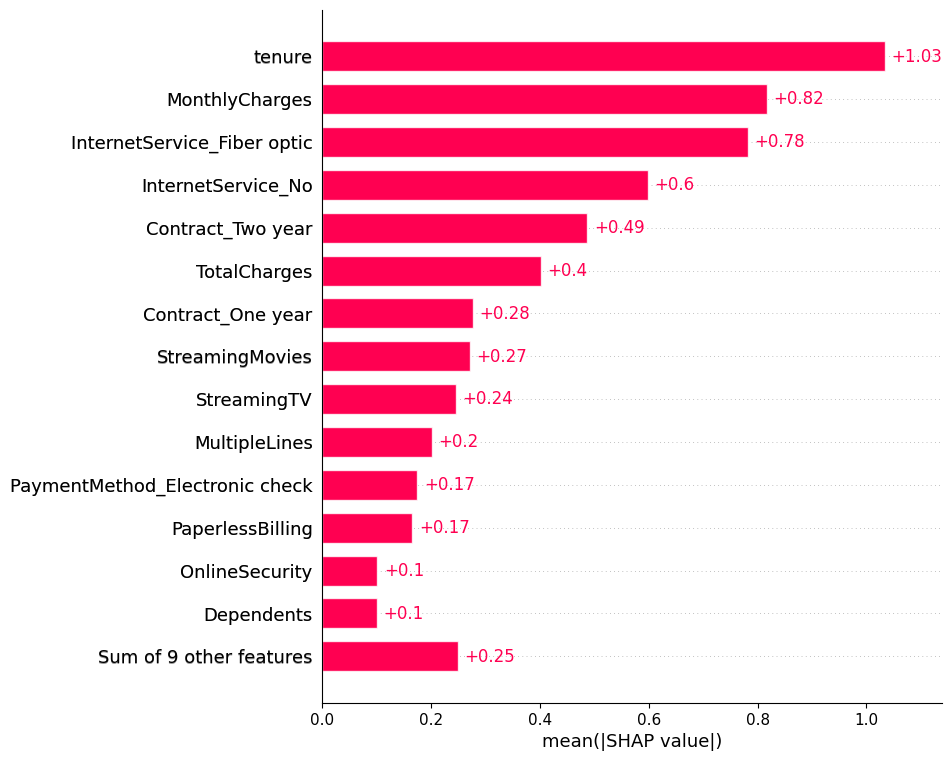

<Figure size 640x480 with 0 Axes>

In [3]:
shap.plots.bar(shap_values, max_display=15)
plt.tight_layout()
plt.savefig('../reports/shap_importance.png')
plt.show()

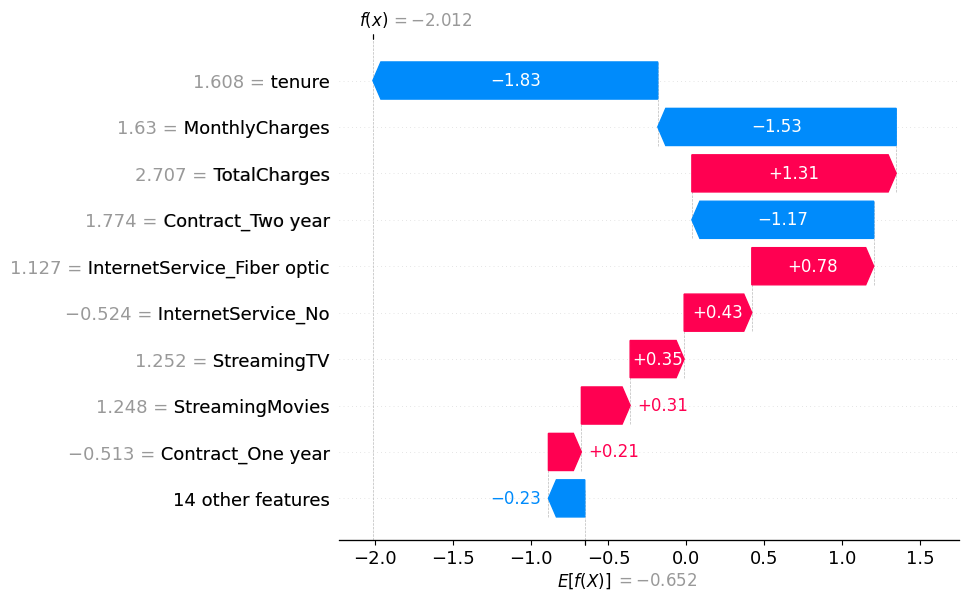

<Figure size 640x480 with 0 Axes>

In [4]:
# Explain first customer in test set
shap.plots.waterfall(shap_values[0])
plt.tight_layout()
plt.savefig('../reports/shap_waterfall.png')
plt.show()

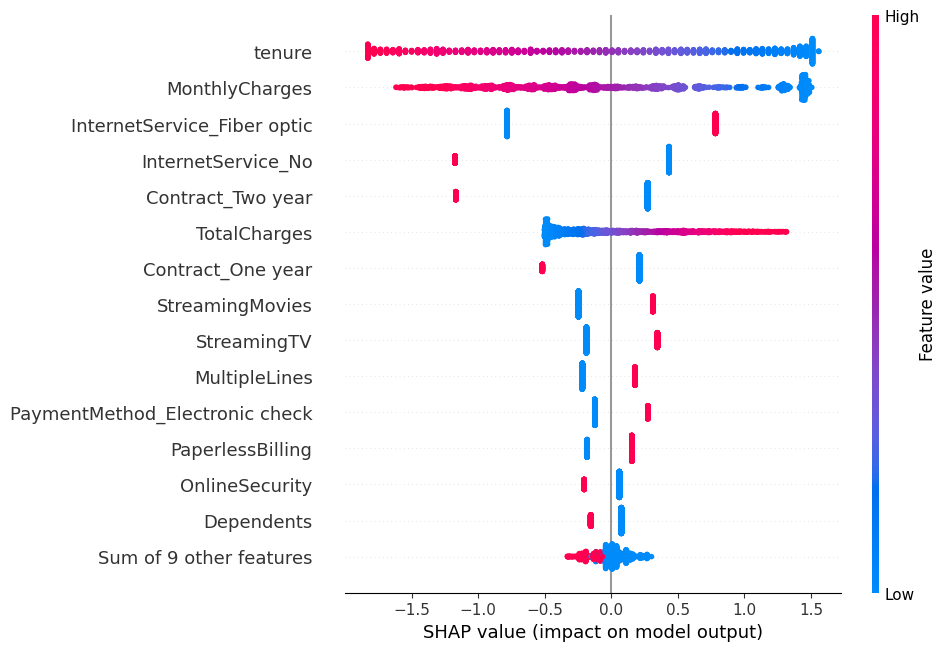

<Figure size 640x480 with 0 Axes>

In [5]:
shap.plots.beeswarm(shap_values, max_display=15)
plt.tight_layout()
plt.savefig('../reports/shap_beeswarm.png')
plt.show()